In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
#===============================================

# Kaggle Credentials (provided by user)
os.environ['KAGGLE_USERNAME'] = "oussamameddori"
os.environ['KAGGLE_KEY'] = "KGAT_6914d0bb5d09ad8289fb93b02f1ac2"

!pip install -q kaggle
!kaggle datasets download -d yash92328/ai4mars-terrainaware-autonomous-driving-on-mars
!unzip -q ai4mars-terrainaware-autonomous-driving-on-mars.zip -d ./ai4mars_data


Dataset URL: https://www.kaggle.com/datasets/yash92328/ai4mars-terrainaware-autonomous-driving-on-mars
License(s): CC0-1.0
100% 5.72G/5.72G [01:15<00:00, 80.9MB/s]



In [ ]:
# For Google Colab: Mount Google Drive to access model weights


IMAGE_PATH = "ai4mars_data/ai4mars-dataset-merged-0.1/msl/images/edr/"
MASK_PATH_TRAIN = "ai4mars_data/ai4mars-dataset-merged-0.1/msl/labels/train/"
MASK_PATH_TEST = "ai4mars_data/ai4mars-dataset-merged-0.1/msl/labels/test/masked-gold-min3-100agree/"
MASK_ROVER = "ai4mars_data/ai4mars-dataset-merged-0.1/msl/images/mxy/"
RANGE_30M = "ai4mars_data/ai4mars-dataset-merged-0.1/msl/images/rng-30m/"
NUM_CLASSES = 5  # 0:soil  1:bedrock  2:sand  3:bigrock  4:NULL(255->4)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import torchvision
import torch.nn.functional as F
from torch.autograd import Variable
from torch.nn.parameter import Parameter

from PIL import Image
import cv2
import albumentations as A

import time, math
import os
from tqdm.notebook import tqdm

!pip install -q segmentation-models-pytorch
!pip install -q torchsummary

from torchsummary import summary
import segmentation_models_pytorch as smp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.0 MB/s eta 0:00:00


In [ ]:
def create_df(path):
    name = []
    for dirname, _, filenames in os.walk(path):
        for filename in filenames:

            imname = filename.split('.')[0]
            imname = imname.replace("_merged","")

            #eliminating all images with rover
            rover_raw = np.array(cv2.imread(MASK_ROVER + imname.replace("EDR","MXY") + ".png"))
            rover = np.zeros((1024,1024))
            rover[:,:] = rover_raw[:,:,0]
            if ((rover == 1).any()): continue
            if (imname == "NLB_432655207EDR_F0160148NCAM00394M1"): continue #no correspondence with rng and mxy masks

            name.append(imname)

    return pd.DataFrame({'id': name}, index = np.arange(0, len(name)))

def create_df_sorted(path):
    name = []
    for filename in sorted(os.listdir(path)):

        imname = filename.split('.')[0]
        imname = imname.replace("_merged","")

        #eliminating all images with rover
        rover_raw = np.array(cv2.imread(MASK_ROVER + imname.replace("EDR","MXY") + ".png"))
        rover = np.zeros((1024,1024))
        rover[:,:] = rover_raw[:,:,0]
        if ((rover == 1).any()): continue
        if (imname == "NLB_432655207EDR_F0160148NCAM00394M1"): continue #no correspondence with rng and mxy masks

        name.append(imname)

    return pd.DataFrame({'id': name}, index = np.arange(0, len(name)))

if (not os.path.isfile("/kaggle/input/mars-models/df_train.csv")):
    df_train = create_df(MASK_PATH_TRAIN)
    df_train.to_csv("/kaggle/working/df_train.csv")
else: df_train = pd.read_csv("/kaggle/input/mars-models/df_train.csv")

if (not os.path.isfile("/kaggle/input/mars-models/df_test.csv")):
    df_test = create_df(MASK_PATH_TEST)
    df_test.to_csv("/kaggle/working/df_test.csv")
else: df_test = pd.read_csv("/kaggle/input/mars-models/df_test.csv")

n_train = len(df_train)
n_test = len(df_test)

print('Total Images Train: ', len(df_train))
print('Total Images Test: ', len(df_test))
print(df_test['id'][0])

Total Images Train:  4221
Total Images Test:  80
NLB_543357370EDR_F0613076NCAM00287M1


In [ ]:
import os

# Create the directory if it doesn't exist
os.makedirs("/kaggle/working", exist_ok=True)

if (not os.path.isfile("/kaggle/input/mars-models/df_train.csv")):
    df_train = create_df(MASK_PATH_TRAIN)
    df_train.to_csv("/kaggle/working/df_train.csv")
else:
    df_train = pd.read_csv("/kaggle/input/mars-models/df_train.csv")

if (not os.path.isfile("/kaggle/input/mars-models/df_test.csv")):
    df_test = create_df(MASK_PATH_TEST)
    df_test.to_csv("/kaggle/working/df_test.csv")
else:
    df_test = pd.read_csv("/kaggle/input/mars-models/df_test.csv")

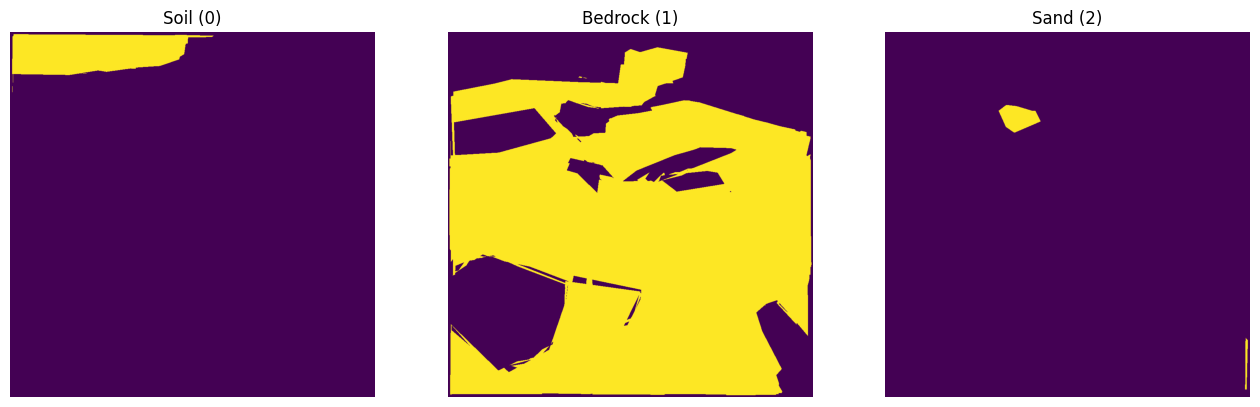

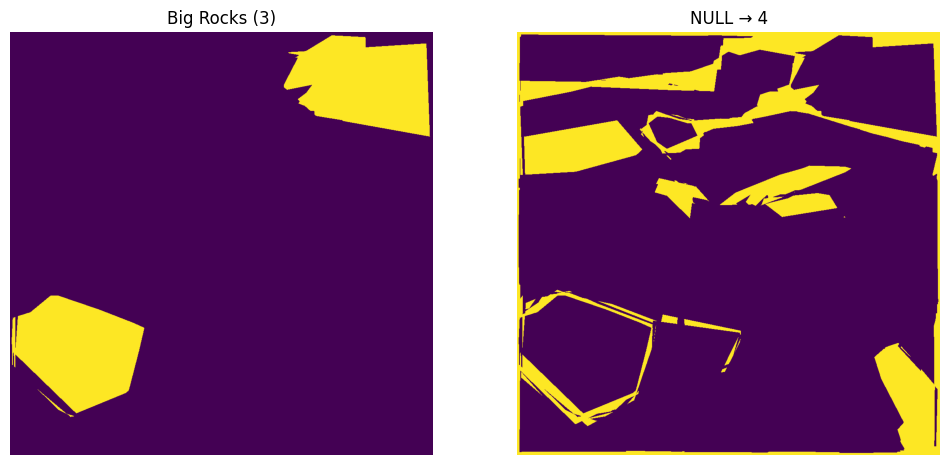

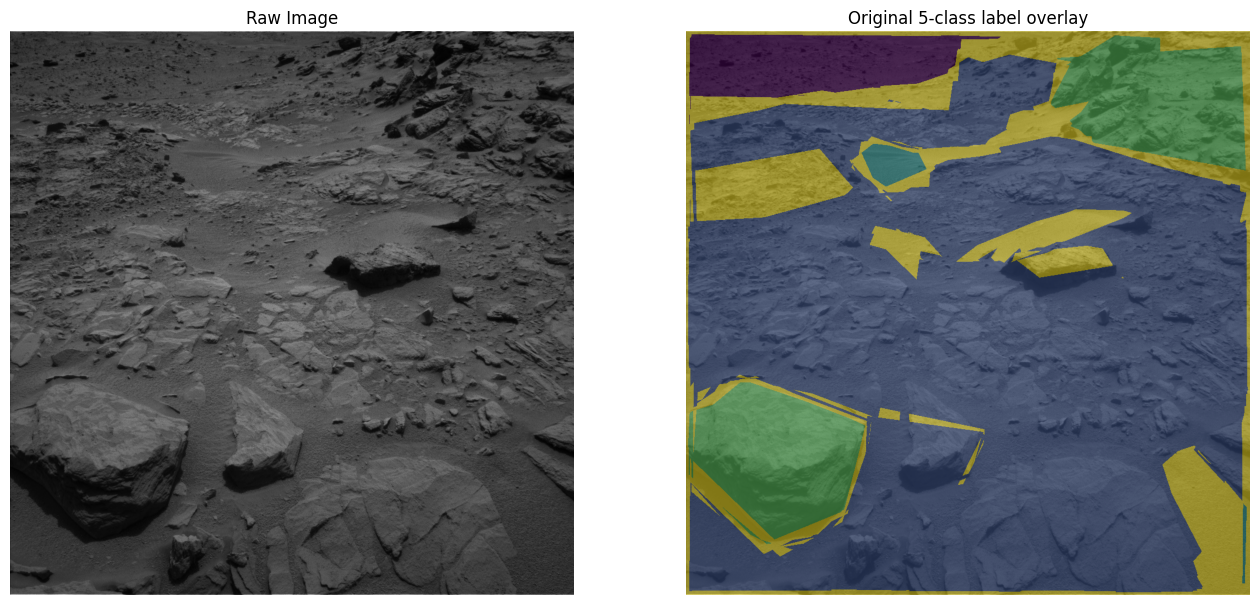

In [ ]:
# Original 5-class labels:
# 0: soil
# 1: bedrock
# 2: sand
# 3: bigrock
# 255: NULL  →  remapped to 4 for display

count = 0
for ix, x in enumerate(df_train['id'].values):

    if (ix < 39): continue

    ground_truth_raw = np.array(cv2.imread(MASK_PATH_TRAIN + x + ".png"))
    img_raw = np.array(cv2.imread(IMAGE_PATH + x + ".JPG"))
    ground_truth = np.zeros((1024, 1024))
    img = np.zeros((1024, 1024))
    ground_truth[:, :] = ground_truth_raw[:, :, 0]
    img[:, :] = img_raw[:, :, 0]

    # Remap NULL (255) to class 4 so every pixel has a valid label [0-4]
    ground_truth[ground_truth == 255] = 4

    ground_truth_0 = np.where(ground_truth == 0, 1, 0)  # soil
    ground_truth_1 = np.where(ground_truth == 1, 1, 0)  # bedrock
    ground_truth_2 = np.where(ground_truth == 2, 1, 0)  # sand
    ground_truth_3 = np.where(ground_truth == 3, 1, 0)  # bigrock
    ground_truth_4 = np.where(ground_truth == 4, 1, 0)  # null

    if ((ground_truth == 0).any() and (ground_truth == 1).any()
            and (ground_truth == 2).any() and (ground_truth == 3).any()):

        # Plot original 5 classes
        fig, ax = plt.subplots(1, 3, figsize=(16, 9))
        ax[0].axis('off'); ax[0].imshow(ground_truth_0); ax[0].set_title('Soil (0)')
        ax[1].axis('off'); ax[1].imshow(ground_truth_1); ax[1].set_title('Bedrock (1)')
        ax[2].axis('off'); ax[2].imshow(ground_truth_2); ax[2].set_title('Sand (2)')

        fig, ax = plt.subplots(1, 2, figsize=(12, 9))
        ax[0].axis('off'); ax[0].imshow(ground_truth_3); ax[0].set_title('Big Rocks (3)')
        ax[1].axis('off'); ax[1].imshow(ground_truth_4); ax[1].set_title('NULL → 4')

        # Image + original label overlay
        fig, ax = plt.subplots(1, 2, figsize=(16, 9))
        ax[0].axis('off')
        ax[0].imshow(img, cmap='gray')
        ax[0].set_title('Raw Image')
        ax[1].axis('off')
        ax[1].imshow(img, cmap='gray')
        ax[1].imshow(ground_truth, alpha=0.5, vmin=0, vmax=4)
        ax[1].set_title('Original 5-class label overlay')

        count += 1
        if count == 1: break


In [ ]:
X_trainval = df_train['id'].values
X_test = df_test['id'].values
X_train, X_val = train_test_split(X_trainval, test_size=0.20, random_state=42)

print('Train Size   : ', len(X_train))
print('Val Size     : ', len(X_val))
print('Test Size    : ', len(X_test))

Train Size   :  3376
Val Size     :  845
Test Size    :  80


In [ ]:
# ─────────────────────────────────────────────
# Dataset & DataLoader
# ─────────────────────────────────────────────
class MarsDataset(Dataset):
    """Loads (image, mask) pairs. Mask pixel values: 0-3 original + 4 for NULL."""

    def __init__(self, img_ids, image_path, mask_path, transform=None):
        self.img_ids    = img_ids
        self.image_path = image_path
        self.mask_path  = mask_path
        self.transform  = transform

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]

        # Load image (grayscale → 3-channel for ImageNet-pretrained backbone)
        img = cv2.imread(self.image_path + img_id + ".JPG")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Load mask
        mask_raw = cv2.imread(self.mask_path + img_id + ".png", cv2.IMREAD_GRAYSCALE)
        mask = mask_raw.astype(np.int64)
        mask[mask == 255] = 4   # remap NULL → class 4

        if self.transform:
            aug = self.transform(image=img, mask=mask.astype(np.uint8))
            img, mask = aug['image'], aug['mask'].long()
        else:
            img  = T.ToTensor()(img)
            mask = torch.tensor(mask, dtype=torch.long)

        return img, mask


# ── Augmentations ────────────────────────────────────────────────────────────
IMG_SIZE = 512   # fine-tuning at higher resolution

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    A.pytorch.ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    A.pytorch.ToTensorV2(),
])

# ── Datasets ─────────────────────────────────────────────────────────────────
train_ds = MarsDataset(X_train, IMAGE_PATH, MASK_PATH_TRAIN, transform=train_transform)
val_ds   = MarsDataset(X_val,   IMAGE_PATH, MASK_PATH_TRAIN, transform=val_transform)

BATCH_SIZE = 2  # keep low for 512px

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
imgs, masks = next(iter(train_loader))
print(f"Image batch : {imgs.shape}  dtype={imgs.dtype}")
print(f"Mask  batch : {masks.shape} dtype={masks.dtype}  unique={masks.unique().tolist()}")


Train batches: 1688 | Val batches: 423
Image batch : torch.Size([2, 3, 512, 512])  dtype=torch.float32
Mask  batch : torch.Size([2, 512, 512]) dtype=torch.int64  unique=[0, 1, 2, 4]


In [ ]:
# ─────────────────────────────────────────────
# DeepLabV3+ Fine-tuning — with Drive checkpointing & auto-resume
# ─────────────────────────────────────────────
import os, torchvision.models.segmentation as seg_models
from google.colab import drive

# ── Mount Drive first ────────────────────────────────────────────────────────
drive.mount('/content/drive', force_remount=False)
SAVE_DIR = "/content/drive/MyDrive/mars_checkpoints/"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 5
EPOCHS      = 8

# ── Build model ──────────────────────────────────────────────────────────────
model = seg_models.deeplabv3_resnet101(
    weights=seg_models.DeepLabV3_ResNet101_Weights.DEFAULT
)
model.classifier[4]     = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
model.aux_classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
model = model.to(DEVICE)

class_weights = torch.tensor([1.0, 1.0, 1.0, 6.0, 0.5], device=DEVICE)
criterion     = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-1)
optimizer     = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler     = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

history       = {"train_loss": [], "val_loss": [], "val_acc": [], "val_miou": []}
START_EPOCH   = 1

# ── Auto-resume: look for the latest per-epoch checkpoint in Drive ────────────
latest_ckpt = None
for ep in range(EPOCHS, 0, -1):
    path = f"{SAVE_DIR}checkpoint_epoch{ep:02d}.pth"
    if os.path.exists(path):
        latest_ckpt = path
        break

if latest_ckpt:
    print(f"🔄 Resuming from: {latest_ckpt}")
    ckpt = torch.load(latest_ckpt, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    history     = ckpt['history']
    START_EPOCH = ckpt['epoch'] + 1
    print(f"✅ Resumed — will train epochs {START_EPOCH} → {EPOCHS}")
else:
    # No per-epoch checkpoint — try loading the original pretrained base
    BASE_CKPT = "/content/drive/MyDrive/ai4mars_deeplabv3V2.pth"
    if os.path.exists(BASE_CKPT):
        ckpt = torch.load(BASE_CKPT, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        print(f"✅ Loaded base checkpoint: {BASE_CKPT}")
    else:
        print("⚠️  No checkpoint found — starting from ImageNet weights only")

print(f"\nFine-tuning on: {DEVICE}  |  IMG_SIZE={IMG_SIZE}  |  Epochs={EPOCHS}")
print(f"Starting from epoch {START_EPOCH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded checkpoint from: /content/drive/MyDrive/ai4mars_deeplabv3V2.pth

Fine-tuning on: cuda  |  IMG_SIZE=512  |  Epochs=8


In [ ]:
# ─────────────────────────────────────────────
# Training Loop — saves checkpoint to Drive after every epoch
# ─────────────────────────────────────────────
def pixel_accuracy(preds, masks):
    correct = (preds == masks).sum().item()
    return correct / masks.numel()

def mean_iou(preds, masks, num_classes=NUM_CLASSES):
    ious = []
    for cls in range(num_classes - 1):
        inter = ((preds == cls) & (masks == cls)).sum().item()
        union = ((preds == cls) | (masks == cls)).sum().item()
        if union > 0:
            ious.append(inter / union)
    return np.mean(ious) if ious else 0.0


torch.cuda.empty_cache()

if START_EPOCH > EPOCHS:
    print("✅ All epochs already complete! Nothing to train.")
else:
    for epoch in range(START_EPOCH, EPOCHS + 1):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        loop = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]", leave=False)
        for imgs, masks in loop:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs['out'], masks)
            loss = loss + 0.4 * criterion(outputs['aux'], masks)

            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        train_loss = running_loss / len(train_loader)

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        val_loss, val_acc, val_miou = 0.0, 0.0, 0.0
        with torch.no_grad():
            for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]", leave=False):
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                out      = model(imgs)['out']
                loss     = criterion(out, masks)
                val_loss += loss.item()
                preds     = out.argmax(dim=1)
                val_acc  += pixel_accuracy(preds, masks)
                val_miou += mean_iou(preds.cpu().numpy(), masks.cpu().numpy())

        val_loss  /= len(val_loader)
        val_acc   /= len(val_loader)
        val_miou  /= len(val_loader)
        scheduler.step(val_miou)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_miou"].append(val_miou)

        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val mIoU: {val_miou:.4f}")

        # ── Save checkpoint to Drive after every epoch ────────────────────────
        ckpt_path = f"{SAVE_DIR}checkpoint_epoch{epoch:02d}.pth"
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history':              history,
        }, ckpt_path)
        print(f"  💾 Checkpoint saved → Drive: checkpoint_epoch{epoch:02d}.pth")

    # ── Final model save ──────────────────────────────────────────────────────
    final_path = f"{SAVE_DIR}deeplabv3_mars_finetune_FINAL.pth"
    torch.save(model.state_dict(), final_path)
    print(f"\n✅ Final model saved → {final_path}")


Epoch 1/8 [train]:   0%|          | 0/1688 [00:00<?, ?it/s]

Epoch 1/8 [val]:   0%|          | 0/423 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.5028 | Val Loss: 0.3470 | Val Acc: 0.8446 | Val mIoU: 0.5308


Epoch 2/8 [train]:   0%|          | 0/1688 [00:00<?, ?it/s]

Epoch 2/8 [val]:   0%|          | 0/423 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 0.4606 | Val Loss: 0.3592 | Val Acc: 0.8493 | Val mIoU: 0.5379


Epoch 3/8 [train]:   0%|          | 0/1688 [00:00<?, ?it/s]

Epoch 3/8 [val]:   0%|          | 0/423 [00:00<?, ?it/s]

Epoch 03 | Train Loss: 0.4396 | Val Loss: 0.3294 | Val Acc: 0.8501 | Val mIoU: 0.5572


Epoch 4/8 [train]:   0%|          | 0/1688 [00:00<?, ?it/s]

In [ ]:
# ─────────────────────────────────────────────
# Training curves
# ─────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_range, history['val_acc'], color='green')
axes[1].set_title('Val Pixel Accuracy'); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_range, history['val_miou'], color='orange')
axes[2].set_title('Val Mean IoU (4 classes)'); axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.show()


In [ ]:
# ─────────────────────────────────────────────
# Cherry-picked visualization
# ─────────────────────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ── Class colours & names ─────────────────────────────────────────────────
CLASS_COLORS = [
    (0.76, 0.60, 0.42),   # 0: soil      – sandy brown
    (0.50, 0.35, 0.20),   # 1: bedrock   – dark brown
    (0.94, 0.85, 0.60),   # 2: sand      – light yellow
    (0.30, 0.30, 0.30),   # 3: bigrock   – dark grey
    (0.20, 0.20, 0.80),   # 4: null      – blue (ignored in training)
]
CLASS_NAMES  = ['Soil', 'Bedrock', 'Sand', 'Big Rock', 'NULL']
cmap_mars    = ListedColormap(CLASS_COLORS)

def colorize(mask_2d):
    """Map integer class mask to an RGB image."""
    h, w   = mask_2d.shape
    rgb    = np.zeros((h, w, 3))
    for cls, color in enumerate(CLASS_COLORS):
        rgb[mask_2d == cls] = color
    return rgb

def denormalize(tensor):
    """Undo ImageNet normalisation and return HWC uint8 array."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.permute(1, 2, 0).cpu().numpy()
    img  = std * img + mean
    return np.clip(img, 0, 1)

# ── Pick an image that has all 4 labelled classes ────────────────────────
model.eval()
cherry_img_tensor = None
cherry_mask_np    = None
cherry_pred_np    = None

for imgs, masks in val_loader:
    for i in range(imgs.shape[0]):
        m = masks[i].numpy()
        # require all 4 terrain classes present
        if all((m == c).any() for c in range(4)):
            cherry_img_tensor = imgs[i].unsqueeze(0).to(DEVICE)
            cherry_mask_np    = m
            with torch.no_grad():
                logits = model(cherry_img_tensor)['out']  # (1, C, H, W)
            cherry_pred_np = logits.argmax(dim=1).squeeze(0).cpu().numpy()
            break
    if cherry_img_tensor is not None:
        break

# ── Plot ──────────────────────────────────────────────────────────────────
img_display  = denormalize(cherry_img_tensor.squeeze(0))
pred_colored = colorize(cherry_pred_np)
gt_colored   = colorize(cherry_mask_np)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Cherry-picked Validation Sample', fontsize=16, fontweight='bold')

axes[0].imshow(img_display);              axes[0].set_title('Raw Image');          axes[0].axis('off')
axes[1].imshow(gt_colored);               axes[1].set_title('Ground Truth');        axes[1].axis('off')
axes[2].imshow(pred_colored);             axes[2].set_title('DeepLabV3+ Prediction'); axes[2].axis('off')

# Legend
patches = [mpatches.Patch(color=c, label=n) for c, n in zip(CLASS_COLORS, CLASS_NAMES)]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=12,
           bbox_to_anchor=(0.5, -0.04), frameon=False)

plt.tight_layout()
plt.show()

# ── Per-class IoU for this single image ──────────────────────────────────
print("\n── Per-class IoU (this image) ──")
for cls in range(4):
    inter = ((cherry_pred_np == cls) & (cherry_mask_np == cls)).sum()
    union = ((cherry_pred_np == cls) | (cherry_mask_np == cls)).sum()
    iou   = inter / union if union > 0 else float('nan')
    print(f"  {CLASS_NAMES[cls]:>8}: {iou:.3f}")


In [ ]:
import os
import shutil
import torch
from google.colab import drive

# ── 1. Save to local Colab storage ──────────────────────────────────────────
save_path = "ai4mars_deeplabv3_finetune.pth"
torch.save({
    'epoch':                EPOCHS,
    'model_state_dict':     model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history':              history,
}, save_path)
print(f"✅ Model saved locally to: {save_path}")

# ── 2. Back up to Google Drive ───────────────────────────────────────────────
drive.mount('/content/drive', force_remount=False)
drive_save_path = "/content/drive/MyDrive/ai4mars_deeplabv3V3_finetune.pth"
shutil.copy(save_path, drive_save_path)
print(f"✅ Model backed up to Google Drive: {drive_save_path}")